In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

In [2]:
BG, CARD= '#0d1117', '#161b22'
BLUE, TEAL, ORNG, ROSE, PURP, YELL = '#1e90ff','#00d4aa','#ff8c42','#ff6b6b','#c084fc','#fbbf24'
PALETTE = [BLUE, TEAL, ORNG, ROSE, PURP, YELL]

In [4]:
def dark_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#8b949e')
    ax.xaxis.label.set_color('#8b949e')
    ax.yaxis.label.set_color('#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

In [6]:
TARGET= 'Historical_Cost_of_Ride'
df= pd.read_csv(r"C:\Users\DELL\Desktop\Price_Pulse\dynamic_pricing.csv")

In [7]:
print("PRICEPLUS")
print(f"Shape: {df.shape}")
print(f"Missing {df.isnull().sum().sum()} | Duplicates: {df.duplicated().sum()}")

PRICEPLUS
Shape: (1000, 10)
Missing 0 | Duplicates: 0


In [8]:
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


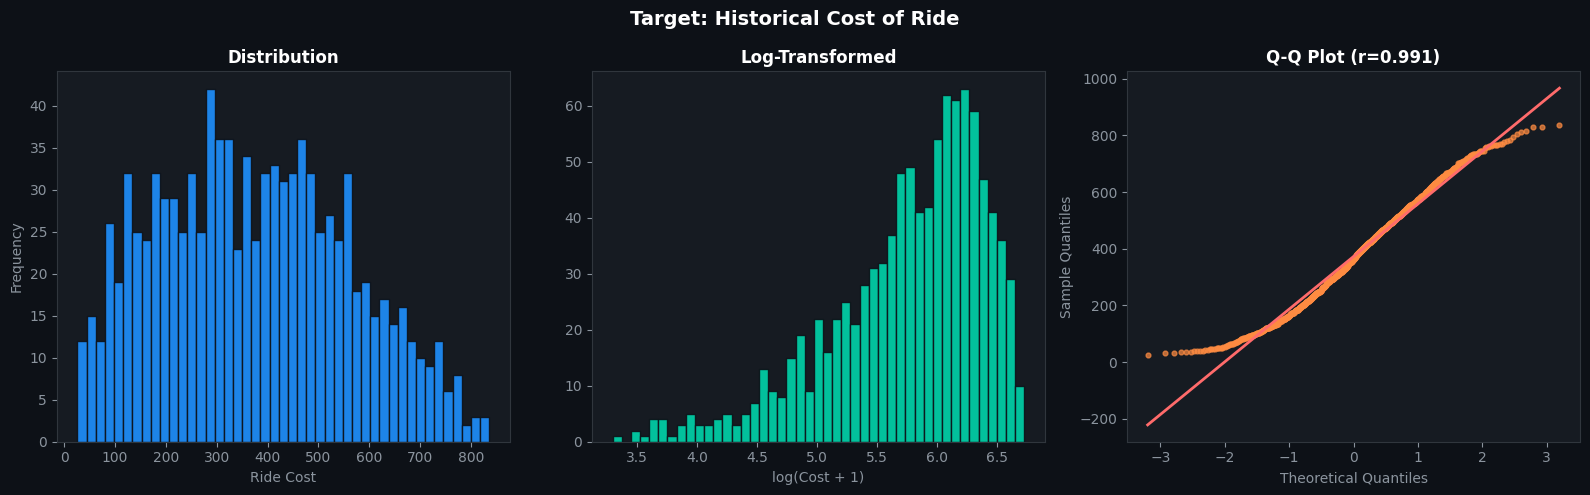

In [ ]:
fig,axes= plt.subplots(1,3, figsize=(16,5), facecolor=BG)
fig.suptitle('Target: Historical Cost of Ride', fontsize=14, fontweight='bold', color='white') 
for ax in axes: dark_ax(ax)
axes[0].hist(df[TARGET], bins=45, color=BLUE, edgecolor=BG, alpha=0.9)
axes[0].set_title('Distribution', color='white', fontweight='bold')
axes[0].set_xlabel('Ride Cost'); axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(df[TARGET]), bins=45, color=TEAL, edgecolor=BG, alpha=0.9)
axes[1].set_title('Log-Transformed', color='white', fontweight='bold')
axes[1].set_xlabel('log(Cost + 1)')
osm,osr= stats.probplot(df[TARGET], dist='norm')[:2][0], stats.probplot(df[TARGET], dist='norm')[0][1]
slope, intercept,r= stats.probplot(df[TARGET], dist='norm')[1]
th_q= stats.probplot(df[TARGET], dist="norm")[0][0]
axes[2].scatter(th_q, osr, color=ORNG, s=12, alpha=0.7)
axes[2].plot(th_q, slope*np.array(th_q)+intercept, color=ROSE, lw=2)
axes[2].set_title(f'Q-Q Plot (r={r:.3f})', color='white', fontweight="bold")
axes[2].set_xlabel('Theoretical Quantiles'); axes[2].set_ylabel('Sample Quantiles')
plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

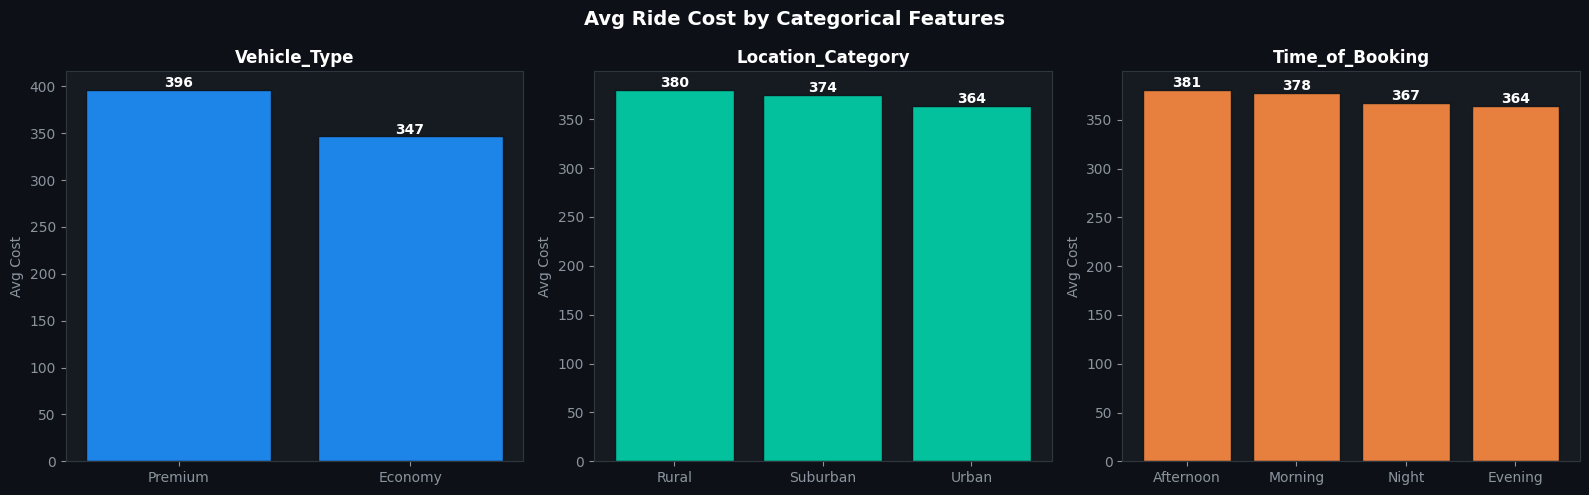

In [19]:
fig,axes= plt.subplots(1,3, figsize=(16,5), facecolor=BG)
fig.suptitle('Avg Ride Cost by Categorical Features', fontsize=14, fontweight='bold', color='white')
for ax in axes: dark_ax(ax)
for ax, col, color in zip(axes,
                          ['Vehicle_Type', 'Location_Category', 'Time_of_Booking'],
                          [BLUE, TEAL, ORNG]):
    c= df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    bars= ax.bar(c.index, c.values, color=color, edgecolor=BG, alpha=0.9)
    ax.set_title(col, color="white", fontweight='bold')
    ax.set_ylabel("Avg Cost")
    for bar, val in zip(bars, c.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, f'{val:.0f}', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/02_categorical_vs_cost.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


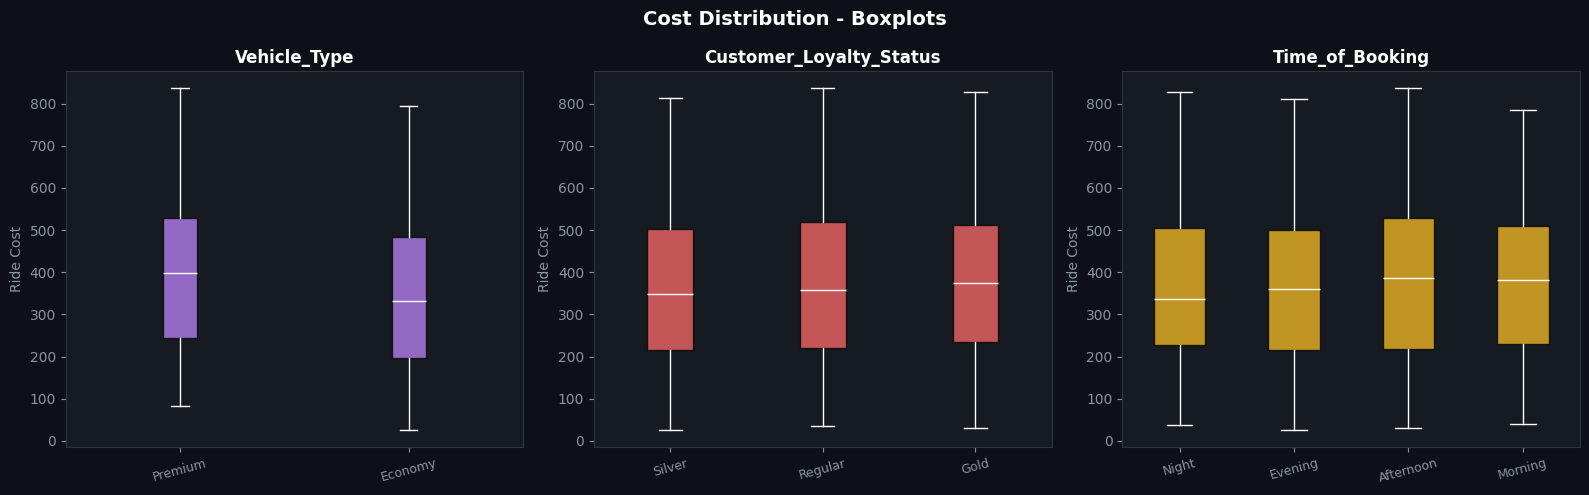

In [22]:
fig,axes= plt.subplots(1,3, figsize=(16,5), facecolor=BG)
fig.suptitle('Cost Distribution - Boxplots', fontsize=14, fontweight='bold', color='white')
for ax in axes: dark_ax(ax)
for ax, col, color in zip(axes,
                          ['Vehicle_Type', 'Customer_Loyalty_Status', 'Time_of_Booking'],
                          [PURP, ROSE, YELL]):
    c= df[col].unique()
    groups=[df[df[col]==i][TARGET].values for i in c]
    bp= ax.boxplot(groups, patch_artist=True, notch=False)
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for el in ['whiskers','caps','medians','fliers']:
        for item in bp.get(el, []):
            item.set_color("white")
    ax.set_xticklabels(c, rotation=15, color='#8b949e', fontsize=9)
    ax.set_title(col, color='white', fontweight='bold')
    ax.set_ylabel('Ride Cost')

plt.tight_layout()
plt.savefig('plots/03_boxplots.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

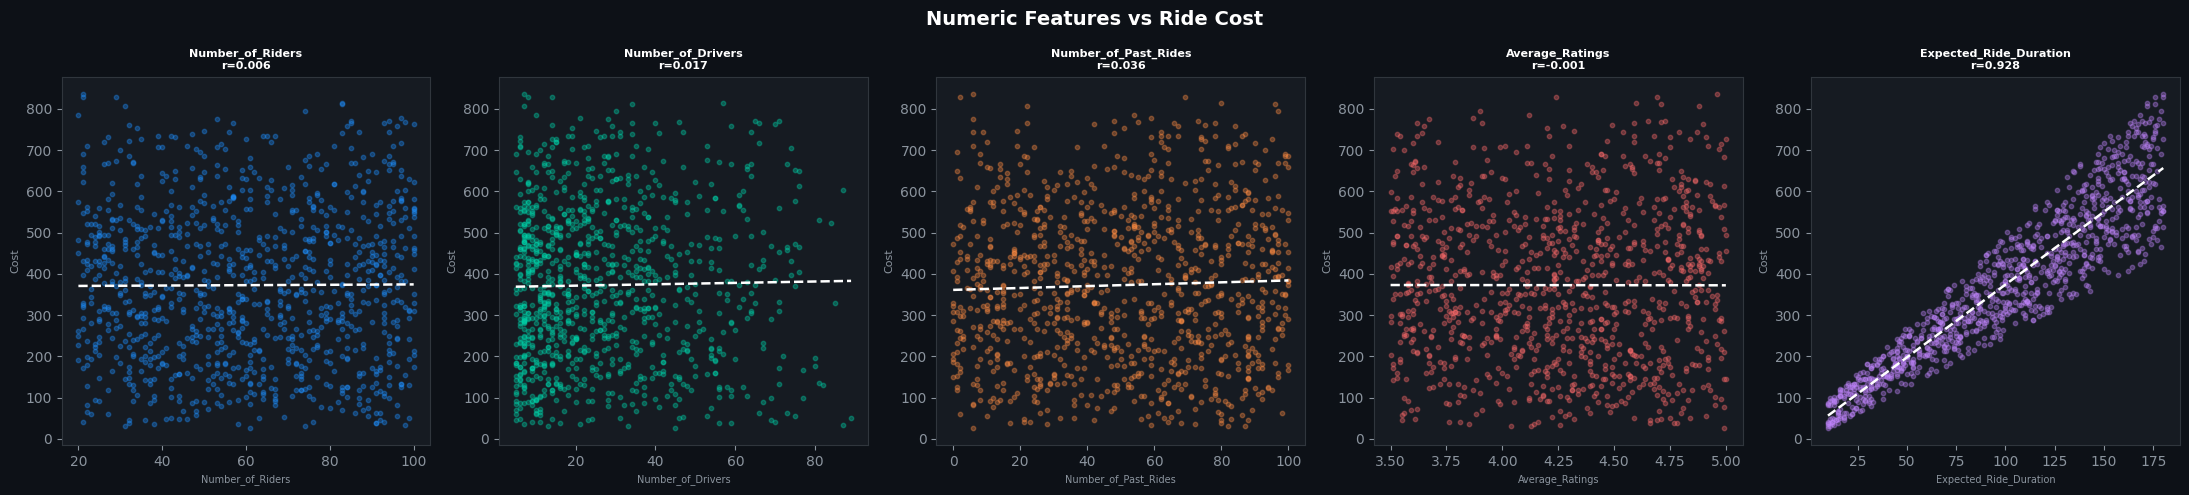

In [23]:
num_feats= ['Number_of_Riders','Number_of_Drivers','Number_of_Past_Rides','Average_Ratings','Expected_Ride_Duration']
fig,axes= plt.subplots(1,5,figsize=(22,5), facecolor=BG)
fig.suptitle('Numeric Features vs Ride Cost', fontsize=14, fontweight='bold', color='white')
for ax in axes: dark_ax(ax)
for ax, feat, color in zip(axes, num_feats, PALETTE):
    ax.scatter(df[feat], df[TARGET], alpha=0.35, s=10, c=color)
    z=np.polyfit(df[feat], df[TARGET],1)
    x1=np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x1, np.poly1d(z)(x1), color='white', lw=1.8, ls='--')
    corr=df[feat].corr(df[TARGET])
    ax.set_title(f'{feat}\nr={corr:.3f}', color='white', fontweight='bold', fontsize=8)
    ax.set_xlabel(feat, fontsize=7); ax.set_ylabel('Cost', fontsize=8)

plt.tight_layout()
plt.savefig('plots/04_numeric_vs_target.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

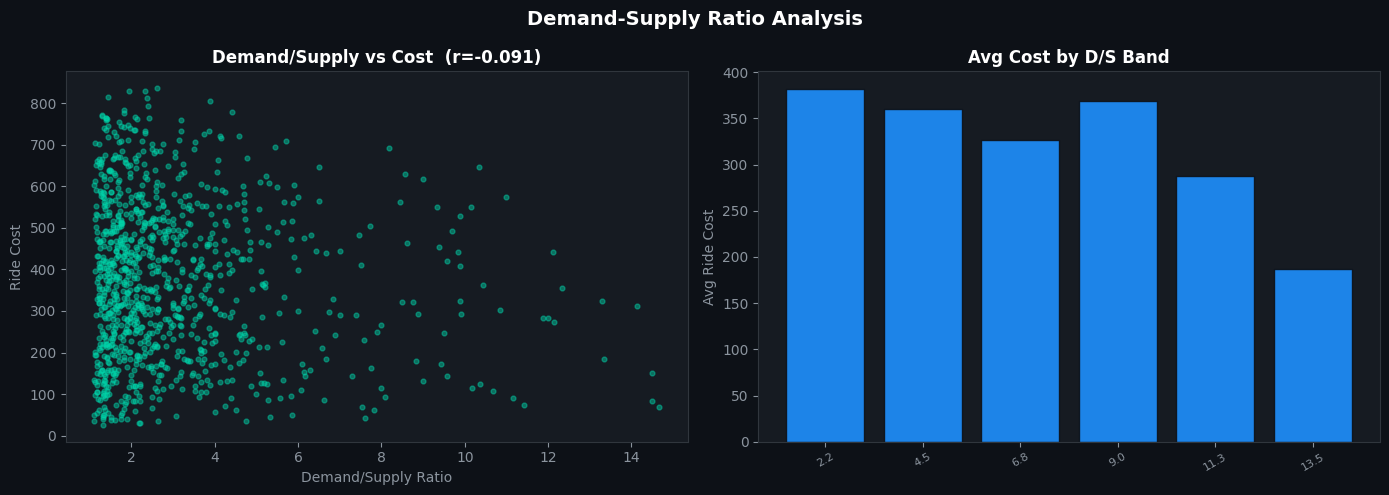

In [25]:
df['demand_supply_ratio']= df['Number_of_Riders']/(df['Number_of_Drivers']+1)
fig,axes= plt.subplots(1,2, figsize=(14,5), facecolor=BG)
fig.suptitle("Demand-Supply Ratio Analysis", fontsize=14, fontweight='bold', color='white')
for ax in axes: dark_ax(ax)
axes[0].scatter(df['demand_supply_ratio'], df[TARGET], alpha=0.45, s=12, c=TEAL)
z=np.polyfit(df['demand_supply_ratio'], df[TARGET], 1)
x1= np.linspace(df['demand_supply_ratio'].min(), df['demand_supply_ratio'].max(), 1)
axes[0].plot(x1, np.poly1d(z)(x1), color=ROSE, lw=2, ls='--')
corr=df["demand_supply_ratio"].corr(df[TARGET])
axes[0].set_title(f'Demand/Supply vs Cost  (r={corr:.3f})', color='white', fontweight='bold')
axes[0].set_xlabel('Demand/Supply Ratio'); axes[0].set_ylabel('Ride Cost')

bins=pd.cut(df['demand_supply_ratio'], bins=6)
grouped=df.groupby(bins, observed=True)[TARGET].mean()
axes[1].bar(range(len(grouped)), grouped.values, color=BLUE, edgecolor=BG, alpha=0.9)
axes[1].set_xticks(range(len(grouped)))
axes[1].set_xticklabels([f'{i.mid:.1f}' for i in grouped.index], rotation=30, fontsize=8, color='#8b949e')
axes[1].set_title('Avg Cost by D/S Band',color='white',fontweight='bold')
axes[1].set_ylabel("Avg Ride Cost")

plt.tight_layout()
plt.savefig("plots/05_demand_suppy.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

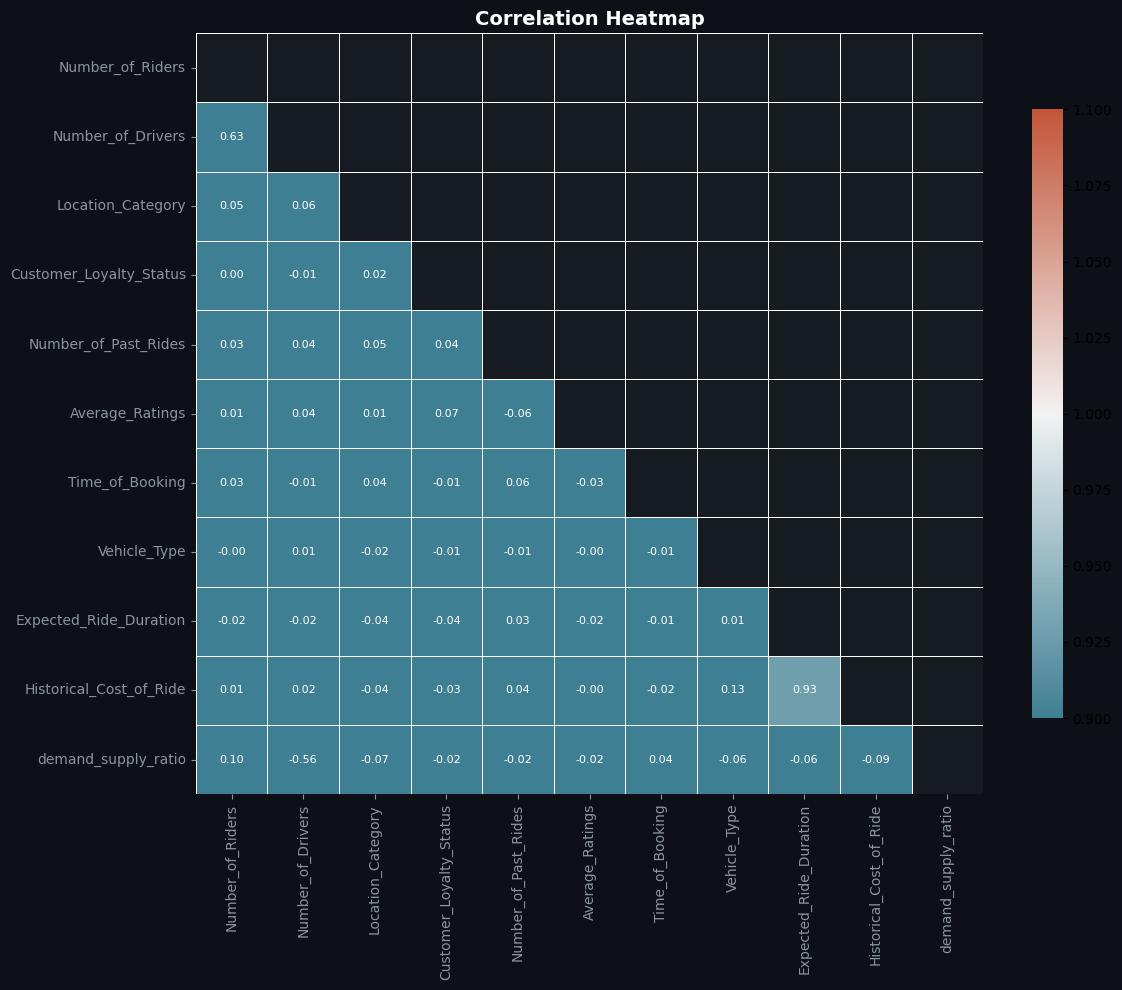

In [27]:
df_corr=df.copy()
for col in ['Location_Category','Customer_Loyalty_Status', 'Time_of_Booking','Vehicle_Type']:
    df_corr[col]= LabelEncoder().fit_transform(df_corr[col].astype(str))
corr= df_corr.select_dtypes(include=np.number).corr()
fig,ax= plt.subplots(figsize=(12,10), facecolor=BG)
ax.set_facecolor(CARD)
m=np.triu(np.ones_like(corr, dtype=bool))
cmap=sns.diverging_palette(220,20,as_cmap=True)
sns.heatmap(corr, mask=m,annot=True,fmt='.2f',cmap=cmap,vmin=1,vmax=1,ax=ax,linewidth=0.5,
            annot_kws={'size':8,'color':'white'}, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Heatmap', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='#8b949e')
plt.tight_layout()
plt.savefig('plots/06_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

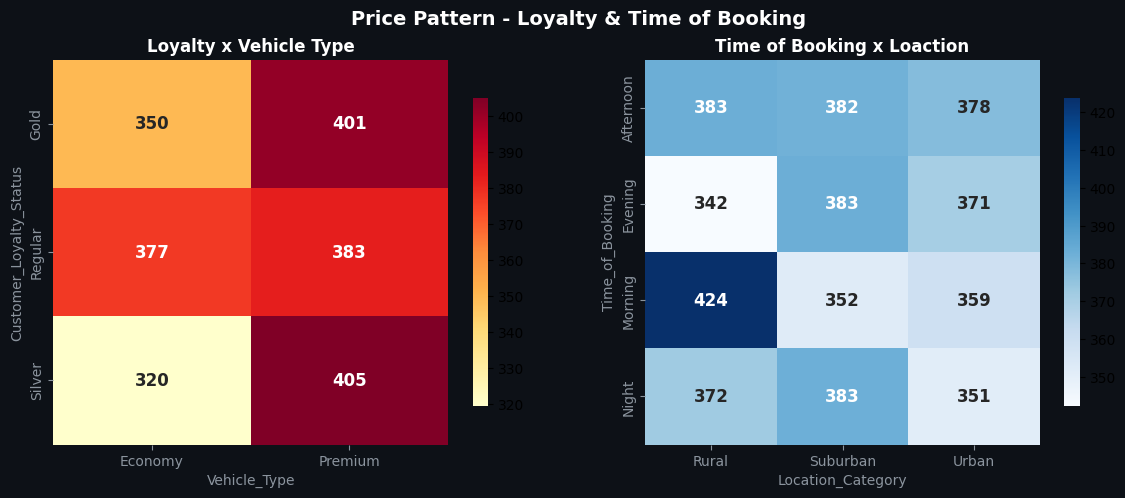

In [30]:
fig,axes=plt.subplots(1,2,figsize=(14,5), facecolor=BG)
fig.suptitle('Price Pattern - Loyalty & Time of Booking', fontsize=14, fontweight='bold', color='white')
for ax in axes: dark_ax(ax)
pi=df.pivot_table(values=TARGET, index='Customer_Loyalty_Status', columns='Vehicle_Type', aggfunc='mean')
sns.heatmap(pi,annot=True, fmt='.0f',cmap='YlOrRd',ax=axes[0],
            annot_kws={'size':12,'fontweight':'bold'}, cbar_kws={'shrink':0.8})
axes[0].set_title('Loyalty x Vehicle Type', color='white',fontweight='bold')
axes[0].tick_params(colors='#8b949e')

pi_2=df.pivot_table(values=TARGET, index='Time_of_Booking', columns='Location_Category',aggfunc='mean')
sns.heatmap(pi_2,annot=True,fmt='.0f',cmap='Blues',ax=axes[1],
            annot_kws={'size':12,'fontweight':'bold'}, cbar_kws={'shrink':0.8})
axes[1].set_title("Time of Booking x Loaction",color='white',fontweight='bold')
axes[1].tick_params(colors='#8b949e')

plt.tight_layout
plt.savefig('plots/07_pivot_heatmap.png',dpi=150, bbox_inches='tight',facecolor=BG)
plt.show()